System Matrix A:
 [[  0.           1.        ]
 [-39.4784176   -3.14159265]]

Calculating state space trajectories across distinct integration engines...


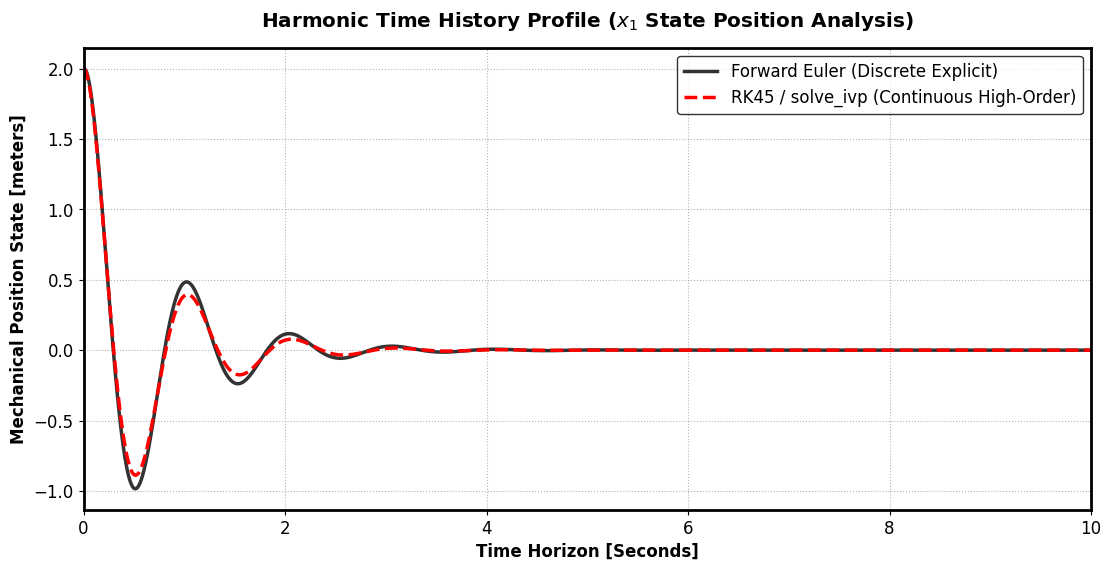

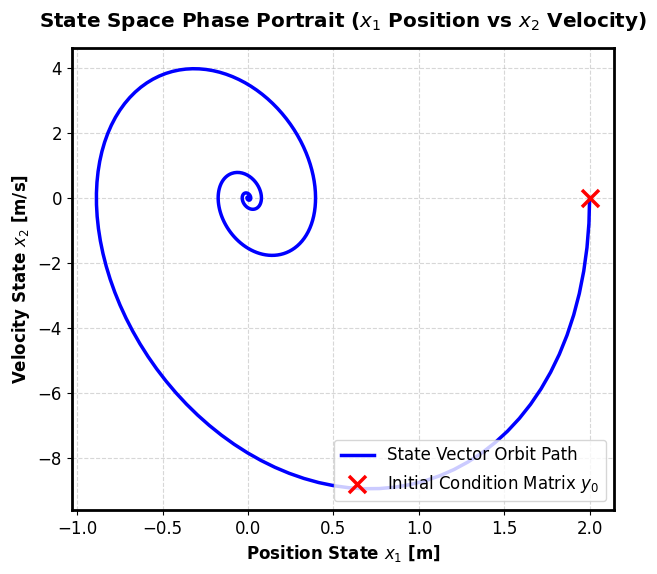


             SYSTEM STABILITY LOG
Calculated Eigenvalue Complex Root 1: (-1.5707963267948966+6.083668013960419j)
Calculated Eigenvalue Complex Root 2: (-1.5707963267948966-6.083668013960419j)
--------------------------------------------------
Theoretical Explanation:
Because the real parts of both roots are strictly NEGATIVE (-1.5707),
the system acts as a structural energy sink. This forms an attracting
stable focus spiral, dragging the physical system back to absolute rest [0,0].


In [1]:
# =============================================================================
# MASTERCLASS CODE: LINEAR ODE VECTOR DYNAMICS & SPRING-MASS-DAMPER COUPLING
# AUTHOR: Ported to Python (.ipynb Colab Edition)
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Configure clean, high-precision visual themes matching professional publications
plt.rcParams.update({
    'font.size': 12,
    'axes.linewidth': 2,
    'lines.linewidth': 2.5,
    'figure.figsize': (13, 6)
})

# -----------------------------------------------------------------------------
# SYSTEM PARAMETERS & MATRICES CONFIGURATION
# -----------------------------------------------------------------------------
w_n = 2.0 * np.pi  # Natural Undamped Angular Frequency (rad/s)
damping_ratio = 0.25 # Underdamped state coefficient (0 < zeta < 1)

# Constructing the State Space Dynamics Matrix 'A'
# Row 1: dot(x) = v
# Row 2: dot(v) = -w_n^2 * x - 2*zeta*w_n * v
A = np.array([
    [0.0, 1.0],
    [-w_n**2, -2.0 * damping_ratio * w_n]
])

# Simulation Time Parameterization
dt = 0.01          # Fixed mathematical integration time slice (seconds)
T_final = 10.0     # Maximum time horizon boundary
t_steps = int(T_final / dt)

# Define Initial State Condition Vector: Position = 2.0 meters, Velocity = 0.0 m/s
y0 = np.array([2.0, 0.0])

print("System Matrix A:\n", A)
print("\nCalculating state space trajectories across distinct integration engines...")

# -----------------------------------------------------------------------------
# ENGINE 1: FORWARD EULER SCHEME (Discrete First-Order Approximation)
# Difference Equation: y_{k+1} = y_k + dt * (A @ y_k) = (I + dt*A) @ y_k
# -----------------------------------------------------------------------------
# Initialize empty storage memory matrices
t_euler = np.zeros(t_steps + 1)
y_euler = np.zeros((2, t_steps + 1))

# Set base baseline anchor indices
t_euler[0] = 0.0
y_euler[:, 0] = y0

# Run the discrete deterministic time loop step forward
for k in range(t_steps):
    t_euler[k+1] = (k + 1) * dt
    # Forward linear acceleration vector updates
    y_euler[:, k+1] = y_euler[:, k] + dt * (A @ y_euler[:, k])

# -----------------------------------------------------------------------------
# ENGINE 2: HIGH-ACCURACY SCIPY SOLVER (RK45 Runge-Kutta Engine)
# High-fidelity equivalent structure to MATLAB's standard legacy 'ode45'
# -----------------------------------------------------------------------------
t_eval_points = np.linspace(0.0, T_final, 1000)

def state_space_harmonic_ode(t, y, system_matrix):
    """
    Returns the vector derivative: dy/dt = A @ y
    """
    return system_matrix @ y

# Run explicit variable-step Runge-Kutta integration pipeline
rk_solution = solve_ivp(
    state_space_harmonic_ode,
    (0.0, T_final),
    y0,
    args=(A,),
    t_eval=t_eval_points,
    rtol=1e-10,  # Replicating MATLAB's odeset accuracy strict tolerances
    atol=1e-12
)

# -----------------------------------------------------------------------------
# VISUALIZATION PIPELINE 1: TIME HISTORY TRAJECTORIES
# -----------------------------------------------------------------------------
fig, ax = plt.subplots()

# Plot Forward Euler trajectory path
ax.plot(t_euler, y_euler[0, :], '-k', alpha=0.8, label='Forward Euler (Discrete Explicit)')

# Plot Runge-Kutta high-fidelity verification line
ax.plot(rk_solution.t, rk_solution.y[0, :], '--r', label='RK45 / solve_ivp (Continuous High-Order)')

# Label layout optimization
ax.set_title("Harmonic Time History Profile ($x_1$ State Position Analysis)", pad=15, fontweight='bold')
ax.set_xlabel("Time Horizon [Seconds]", fontweight='bold')
ax.set_ylabel("Mechanical Position State [meters]", fontweight='bold')
ax.set_xlim(0.0, T_final)
ax.grid(True, linestyle=":", color='gray', alpha=0.6)
ax.legend(loc='upper right', frameon=True, edgecolor='black')
plt.show()

# -----------------------------------------------------------------------------
# VISUALIZATION PIPELINE 2: STATE SPACE PHASE PORTRAIT
# Plots Position (x-axis) vs Velocity (y-axis) to show conservation patterns
# -----------------------------------------------------------------------------
fig_phase, ax_phase = plt.subplots(figsize=(7, 6))

# Plot the geometric state flow orbit pattern captured by the RK45 engine
ax_phase.plot(rk_solution.y[0, :], rk_solution.y[1, :], '-b', label='State Vector Orbit Path')
# Mark the initial conditions state point vector
ax_phase.scatter(y0[0], y0[1], color='red', marker='x', s=150, zorder=5, label='Initial Condition Matrix $y_0$')

ax_phase.set_title("State Space Phase Portrait ($x_1$ Position vs $x_2$ Velocity)", pad=15, fontweight='bold')
ax_phase.set_xlabel("Position State $x_1$ [m]", fontweight='bold')
ax_phase.set_ylabel("Velocity State $x_2$ [m/s]", fontweight='bold')
ax_phase.grid(True, linestyle="--", alpha=0.5)
ax_phase.legend(loc='lower right')
plt.show()

# -----------------------------------------------------------------------------
# ANALYTICAL STABILITY CHECK: EIGENVALUES VERIFICATION
# Characteristic roots matrix evaluation
# -----------------------------------------------------------------------------
eigenvalues, eigenvectors = np.linalg.eig(A)
print("\n" + "="*50)
print("             SYSTEM STABILITY LOG")
print("="*50)
print(f"Calculated Eigenvalue Complex Root 1: {eigenvalues[0]}")
print(f"Calculated Eigenvalue Complex Root 2: {eigenvalues[1]}")
print("-"*50)
print("Theoretical Explanation:")
print("Because the real parts of both roots are strictly NEGATIVE (-1.5707),")
print("the system acts as a structural energy sink. This forms an attracting")
print("stable focus spiral, dragging the physical system back to absolute rest [0,0].")
print("="*50)